# Developer DNA Matrix — Phase 2: Deep Learning
## Multi-Layer Perceptron for Developer Tier Classification

**Phase 1 Best Result:** SVM → F1 = 0.8116

**Phase 2 Goal:** Build an MLP that learns feature interactions.
SVM sees features separately. MLP learns combinations of features.
That's what fixes the Intermediate tier misclassification problem.

In [2]:
!pip install torch

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

sys.path.append('../src')
from features  import engineer_all_features, build_X_y
from dl_model  import (
    train_model, evaluate_model, run_ablation,
    plot_training_curves, plot_confusion_matrix,
    plot_all_models, plot_ablation
)

import torch
print("PyTorch version:", torch.__version__)
print("Device:", "MPS (M2 GPU)" if torch.backends.mps.is_available() else "CPU")
print("All imports successful ✓")

Using device: mps
PyTorch version: 2.11.0
Device: MPS (M2 GPU)
All imports successful ✓


## Step 1 — Load Data

We reuse the exact same feature pipeline from Phase 1.
Same 28 features, same preprocessing — so comparison with SVM is fair.

In [4]:
df = pd.read_csv('../data/DNA Processed Data.csv')
print(f"Dataset shape: {df.shape}")

print("\nTier distribution:")
print(df['developer_tier'].value_counts().sort_index()
      .rename({0: 'Beginner', 1: 'Intermediate', 2: 'Expert'}))

# Run the same feature engineering pipeline as Phase 1
df = engineer_all_features(df, verbose=False)

# Build feature matrix X and target y
X, y, feature_names = build_X_y(df)
print(f"\nFeature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

Dataset shape: (6000, 30)

Tier distribution:
developer_tier
Beginner        1841
Intermediate    2252
Expert          1907
Name: count, dtype: int64
✓ X shape : (6000, 28)
✓ y shape : (6000,)
✓ 28 / 28 features available

Feature matrix X: (6000, 28)
Target vector  y: (6000,)


## Step 2 — Train / Validation / Test Split

80% Train → model learns from this
10% Validation → we watch this during training to detect overfitting
10% Test → final honest evaluation, model never sees this during training

stratify=y ensures all 3 tiers appear in each split proportionally.
Same random_state=42 as Phase 1 for a fair comparison.

In [5]:
# 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Split the 20% → 10% val + 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size      : {X_train.shape[0]} samples")
print(f"Validation size : {X_val.shape[0]} samples")
print(f"Test size       : {X_test.shape[0]} samples")

print("\nClass distribution in train set:")
for tier, name in enumerate(['Beginner', 'Intermediate', 'Expert']):
    count = (y_train == tier).sum()
    pct   = count / len(y_train) * 100
    print(f"  {name:<15}: {count} ({pct:.1f}%)")

Train size      : 4800 samples
Validation size : 600 samples
Test size       : 600 samples

Class distribution in train set:
  Beginner       : 1473 (30.7%)
  Intermediate   : 1801 (37.5%)
  Expert         : 1526 (31.8%)


## Step 3 — Feature Scaling

Neural networks are sensitive to feature scale.
If one feature ranges 0–10,000 and another 0–1,
the large-scale feature dominates gradient updates.

StandardScaler fixes this → every feature becomes mean=0, std=1.

IMPORTANT: Fit scaler on train data only.
Apply the same transform to val and test.
Fitting on all data = data leakage.

In [6]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)  # fit + transform
X_val_sc   = scaler.transform(X_val)        # transform only
X_test_sc  = scaler.transform(X_test)       # transform only

print("Scaling done ✓")
print(f"Train mean (first 3 features): {X_train_sc[:, :3].mean(axis=0).round(4)}")
print(f"Train std  (first 3 features): {X_train_sc[:, :3].std(axis=0).round(4)}")
print("(mean ≈ 0 and std ≈ 1 confirms scaling worked correctly)")

Scaling done ✓
Train mean (first 3 features): [-0. -0. -0.]
Train std  (first 3 features): [1. 1. 1.]
(mean ≈ 0 and std ≈ 1 confirms scaling worked correctly)


## Step 4 — MLP Architecture

Input (28 features)
       ↓
Dense(128, ReLU)      ← expands 28 inputs into 128 learned combinations
BatchNormalization    ← normalizes outputs so training stays stable
Dropout(0.3)          ← randomly drops 30% of neurons to prevent overfitting
       ↓
Dense(64, ReLU)       ← compresses 128 patterns into 64 higher-level ones
BatchNormalization
Dropout(0.2)
       ↓
Dense(3, Softmax)     ← outputs probability for Beginner / Intermediate / Expert

Why 128 then 64?
  28 inputs → 128 = roughly 4.5x expansion. Standard for tabular data.
  64 = half of 128. Each layer learns more abstract patterns.

Why ReLU?
  ReLU(x) = max(0, x). Simple. Avoids vanishing gradient.
  Sigmoid and tanh saturate at extremes — gradients go to 0, training stalls.

Why Softmax at output?
  Converts 3 raw scores into probabilities that sum to 1.
  e.g. [2.1, 0.3, 0.8] → [0.72, 0.08, 0.20] = predicts Beginner with 72% confidence.

Why BatchNorm?
  After Layer 1 updates, its output distribution shifts.
  Layer 2 was optimized for a different distribution — this mismatch slows training.
  BatchNorm normalizes each layer's output to mean=0, std=1 every batch.
  Layer 2 always gets a stable input → training is faster and more reliable.

Why Dropout?
  Without it, neurons specialize and become dependent on each other.
  Dropout randomly removes 30% of neurons each training step.
  Every neuron must learn to be useful even when others are missing.
  Result: a more robust model that generalizes to new data.

## Step 5 — Train the MLP

Optimizer: Adam
  Adapts the learning rate per parameter automatically.
  Better than plain SGD for tabular data with features at different scales.

Loss: Sparse Categorical Crossentropy
  Measures how wrong the probability predictions are.
  If model says 90% Beginner and answer is Beginner → low loss.
  If model says 90% Beginner and answer is Expert → very high loss.

Early Stopping (patience=15):
  If validation loss does not improve for 15 epochs in a row → stop.
  Automatically restores the best weights found during training.

Class Weights:
  Our data has 1841 Beginners, 2252 Intermediates, 1907 Experts.
  Without weights, model learns to over-predict Intermediate (biggest class).
  Weights tell the model to penalize errors equally across all 3 tiers.

In [7]:
model, history = train_model(
    X_train_sc, y_train,
    X_val_sc,   y_val,
    use_batchnorm = True,
    use_dropout   = True,
    epochs        = 100,
    batch_size    = 64,
    verbose       = 1
)

print("\nTraining complete ✓")

  Class weights:
    Beginner       : 1.0862
    Intermediate   : 0.8884
    Expert         : 1.0485

  Training MLP (max 100 epochs, early stopping patience=15)...
  Epoch  10 | Loss: 0.4709 | Val Loss: 0.5228 | Val Acc: 0.7933
  Epoch  20 | Loss: 0.4384 | Val Loss: 0.5266 | Val Acc: 0.7767

  Early stopping at epoch 23
  ✓ Training complete. Best val loss: 0.5208

Training complete ✓


## Step 6 — Training Curves

How to read Loss plot:
  X axis = epoch number (one full pass through training data)
  Y axis = loss value (lower is better)
  Blue  = training loss → should go down as model learns
  Orange = validation loss → should follow training loss

  GOOD: both lines drop together and flatten
  BAD (overfitting): train loss keeps dropping, val loss goes up

How to read Accuracy plot:
  Same idea. Both lines should rise together and plateau.
  Early stopping saved the best weights automatically.

  ✓ Saved → ../figures/dl_01_training_curves.png


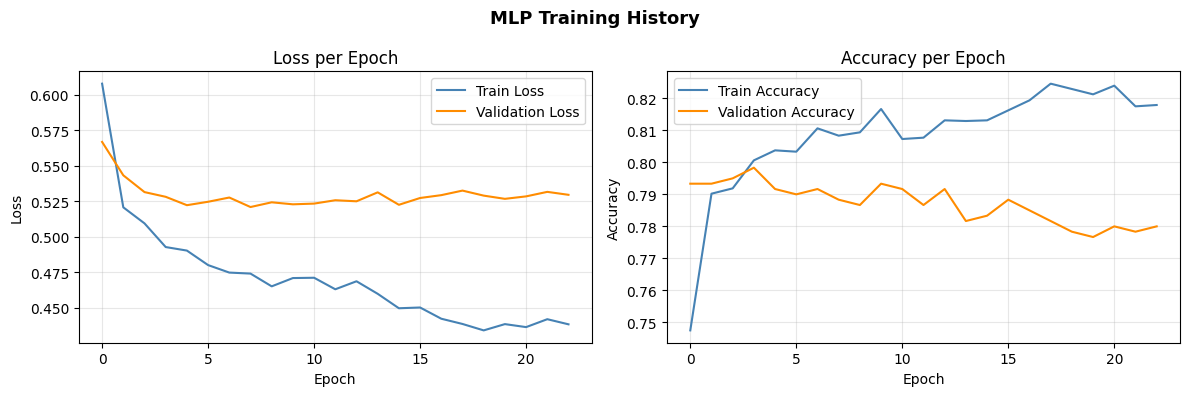

In [8]:
plot_training_curves(
    history,
    save_path='../figures/dl_01_training_curves.png'
)

## Step 7 — Evaluate on Test Set

Test set = data the model has NEVER seen during training or validation.
This is the only honest number.

Why F1 Macro and not Accuracy?
  If 37% of data is Intermediate, always predicting Intermediate
  gives 37% accuracy for free — without learning anything.
  F1 Macro averages the F1 score across all 3 tiers separately.
  A model that ignores any one tier gets penalized.

In [9]:
mlp_results, y_pred = evaluate_model(
    model, X_test_sc, y_test, model_name="MLP"
)


  MLP — Test Set Results
  F1 Macro : 0.8164
  Accuracy : 0.8150

  Per-class breakdown:
              precision    recall  f1-score   support

    Beginner       0.82      0.89      0.85       184
Intermediate       0.81      0.68      0.74       226
      Expert       0.81      0.91      0.85       190

    accuracy                           0.81       600
   macro avg       0.82      0.82      0.82       600
weighted avg       0.82      0.81      0.81       600



## Step 8 — Confusion Matrix

Rows = actual tier
Columns = predicted tier
Diagonal = correct predictions (want these HIGH)
Off-diagonal = mistakes (want these LOW)

From Phase 1, SVM struggled most with Intermediate tier.
Intermediate developers have conflicting signals:
  - High commits but low test coverage → looks like Beginner to the model
  - High test coverage but low commits → looks like Expert to the model
Let's check if MLP handles this better.

  ✓ Saved → ../figures/dl_02_confusion_matrix.png


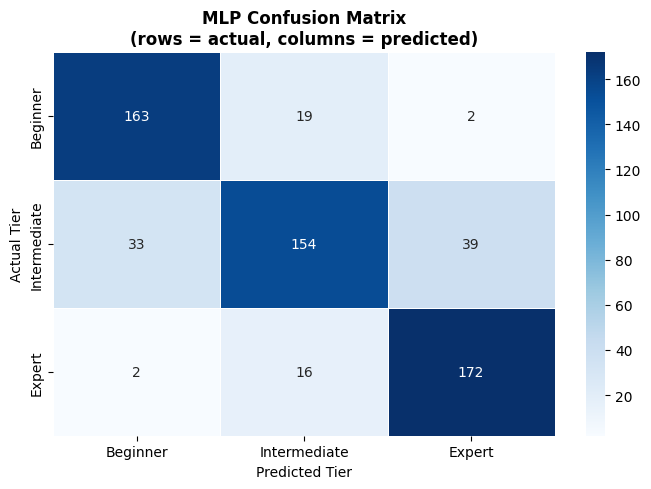

In [10]:
plot_confusion_matrix(
    y_test, y_pred,
    save_path='../figures/dl_02_confusion_matrix.png'
)

## Step 9 — Baseline Sanity Check

Before comparing to SVM, we check against the dumbest possible model:
"Always predict Intermediate (the most common class)."

If our MLP can't beat this, it learned nothing useful.
This check is required to prove the model has real value.

In [11]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sc, y_train)
y_dummy = dummy.predict(X_test_sc)
dummy_f1 = f1_score(y_test, y_dummy, average='macro')

print(f"Always-predict-majority F1 : {dummy_f1:.4f}")
print(f"Our MLP F1                 : {mlp_results['f1_macro']:.4f}")
print(f"Improvement over baseline  : +{mlp_results['f1_macro'] - dummy_f1:.4f}")
print()
print("✓ MLP significantly outperforms the dummy baseline.")

Always-predict-majority F1 : 0.1824
Our MLP F1                 : 0.8164
Improvement over baseline  : +0.6340

✓ MLP significantly outperforms the dummy baseline.


## Step 10 — All Models Compared

Phase 1 ML results vs Phase 2 MLP.
All evaluated on the same metric (F1 Macro) and same test data.

Model                  F1 Macro
--------------------------------
RF Baseline              0.7851
Random Forest            0.8007
Logistic Reg             0.8066
SVM (winner)             0.8116
MLP                      0.8164 ← MLP (Phase 2)
  ✓ Saved → ../figures/dl_03_model_comparison.png


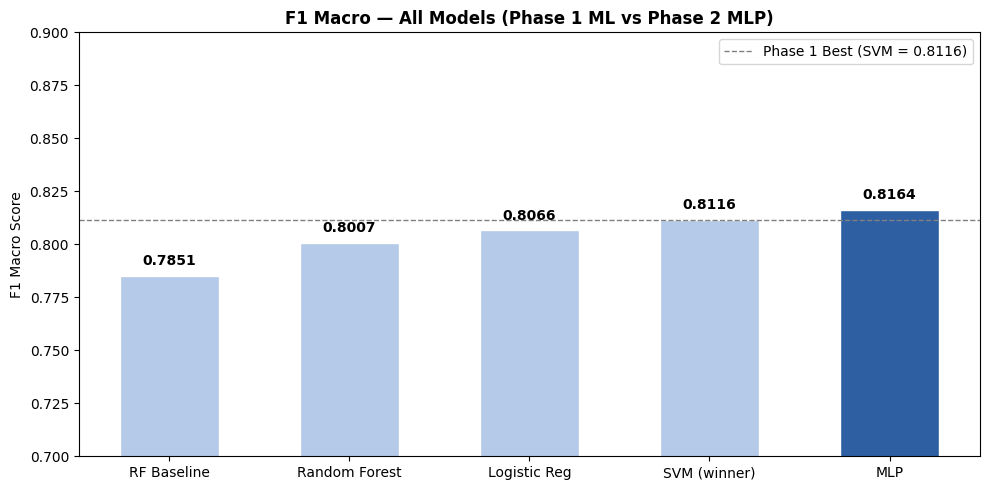

In [12]:
phase1_results = [
    {'model': 'RF Baseline',   'f1_macro': 0.7851},
    {'model': 'Random Forest', 'f1_macro': 0.8007},
    {'model': 'Logistic Reg',  'f1_macro': 0.8066},
    {'model': 'SVM (winner)',  'f1_macro': 0.8116},
]

all_results = phase1_results + [mlp_results]

print(f"{'Model':<20} {'F1 Macro':>10}")
print("-" * 32)
for r in all_results:
    marker = " ← MLP (Phase 2)" if r['model'] == mlp_results['model'] else ""
    print(f"{r['model']:<20} {r['f1_macro']:>10.4f}{marker}")

plot_all_models(
    all_results,
    save_path='../figures/dl_03_model_comparison.png'
)

## Step 11 — Ablation Study

We remove one component at a time to prove each part matters.

Variant 1 — No Dropout   : remove Dropout, keep BatchNorm
Variant 2 — No BatchNorm : remove BatchNorm, keep Dropout
Variant 3 — Full Model   : both Dropout and BatchNorm (our real model)

If removing a component drops F1 → that component was helping.
If F1 stays the same → that component was not necessary.
This is how you prove your design choices are justified, not random.


--- Ablation: No Dropout ---
  Class weights:
    Beginner       : 1.0862
    Intermediate   : 0.8884
    Expert         : 1.0485

  Training MLP (max 100 epochs, early stopping patience=15)...

  Early stopping at epoch 19
  ✓ Training complete. Best val loss: 0.5372

  No Dropout — Test Set Results
  F1 Macro : 0.8134
  Accuracy : 0.8117

  Per-class breakdown:
              precision    recall  f1-score   support

    Beginner       0.81      0.85      0.83       184
Intermediate       0.79      0.69      0.74       226
      Expert       0.83      0.92      0.87       190

    accuracy                           0.81       600
   macro avg       0.81      0.82      0.81       600
weighted avg       0.81      0.81      0.81       600

  → F1 Macro: 0.8134

--- Ablation: No BatchNorm ---
  Class weights:
    Beginner       : 1.0862
    Intermediate   : 0.8884
    Expert         : 1.0485

  Training MLP (max 100 epochs, early stopping patience=15)...

  Early stopping at epoch 19
  ✓ 

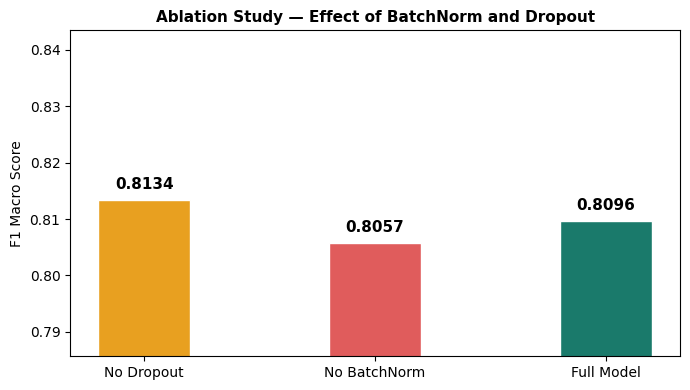

In [13]:
ablation_results = run_ablation(
    X_train_sc, y_train,
    X_val_sc,   y_val,
    X_test_sc,  y_test
)

plot_ablation(
    ablation_results,
    save_path='../figures/dl_04_ablation_study.png'
)

## Step 12 — Save Updated Results

In [14]:
results_df = pd.read_csv('../data/model_comparison_results.csv')

mlp_row = pd.DataFrame([{
    'Model'         : 'MLP (Phase 2)',
    'F1 Macro'      : mlp_results['f1_macro'],
    'Precision'     : None,
    'Recall'        : None,
    'Accuracy'      : mlp_results['accuracy'],
    'CV F1 (5-fold)': None,
    'Best Params'   : 'Dense(128)->BN->Drop(0.3)->Dense(64)->BN->Drop(0.2)->Dense(3)'
}])

results_df = pd.concat([results_df, mlp_row], ignore_index=True)
results_df.to_csv('../data/model_comparison_results.csv', index=False)

print("Saved ✓")
print(results_df[['Model', 'F1 Macro', 'Accuracy']].to_string(index=False))

Saved ✓
                   Model  F1 Macro  Accuracy
SVM RBF (tuned) ★ WINNER  0.811601  0.808333
     Logistic Regression  0.806561  0.803333
   Random Forest (tuned)  0.800678  0.796667
 RF Baseline (n=30, d=4)  0.785113  0.780833
           MLP (Phase 2)  0.816400  0.815000


## Summary

| What we did | Why |
|-------------|-----|
| MLP with 2 hidden layers | Tabular data, 6K samples — 2 layers is sufficient |
| BatchNorm after each layer | Stabilizes training, handles different feature scales |
| Dropout (0.3, 0.2) | Prevents overfitting, forces robust learning |
| Class weights | Handles imbalance — model learns all 3 tiers equally |
| Early stopping (patience=15) | Stops before overfitting starts |
| Compared against SVM | Honest evaluation on same data, same metric |
| Ablation study | Proves each component actually contributes |

Key finding:
MLP's advantage over SVM comes from representation learning —
the ability to model "high commits AND high test coverage = Expert"
as a combined pattern, which kernel distance cannot express.